In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [3]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_test.shape

(10000, 28, 28)

In [6]:
#Reshape,...1 means b&w channel
x_train=x_train.reshape(60000,28,28,1)
x_test=x_test.reshape(10000,28,28,1)

In [7]:
#normalization
x_train=x_train/255
x_test=x_test/255

In [8]:
#Defining Model
model=Sequential()

#Adding convolutional layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))

#Adding Pooling layer
model.add(MaxPool2D(2,2))

#Adding Fully connected layer
model.add(Flatten())
model.add(Dense(100,activation='relu'))

#Adding output layer
model.add(Dense(10,activation='softmax'))

C:\Users\adith\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [10]:
model.fit(x_train,y_train,epochs=10,batch_size=1000)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8513 - loss: 0.5895
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.9453 - loss: 0.1876
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9669 - loss: 0.1174
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.9761 - loss: 0.0854
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.9811 - loss: 0.0681
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.9841 - loss: 0.0564
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9863 - loss: 0.0494
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9879 - loss: 0.0439
Epoch 9/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9888 - loss: 0.0398
Epoch 10/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9902 - loss: 0.0349


In [11]:
model.evaluate(x_test,y_test,batch_size=1000)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9847 - loss: 0.0442


[0.044238872826099396, 0.9847000241279602]

In [12]:
!pip install opencv-python



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\adith\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Predicted Digit: 8


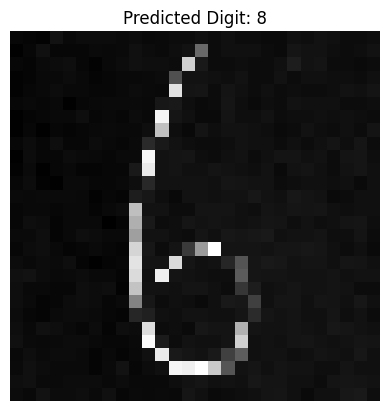

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("test_6.jpg", cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (28, 28))

# Invert image (MNIST = white digit on black background)
img = 255 - img

# Normalize
img = img / 255

# Reshape for CNN
img = img.reshape(1, 28, 28, 1)

# Predict
prediction = model.predict(img)
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

# Display image
plt.imshow(img.reshape(28, 28), cmap="gray")
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis("off")
plt.show()


In [14]:
import numpy as np
predictions =model.predict(x_test[:5])
predicted_classes = np.argmax(predictions,axis=1)
print("actual label first 5",y_test[:5])
print("predicted label first 5",predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
actual label first 5 [7 2 1 0 4]
predicted label first 5 [7 2 1 0 4]


In [15]:
!pip install scikit-image



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\adith\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
import numpy as np
from skimage.io import imread
from skimage.transform import resize
img='test_6.jpg'
img1=imread(img)
img2=resize(img1,(1,28,28,1))
img3=img2/255
pred=model.predict(img3)

pred1=np.argmax(pred)
pred1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


np.int64(1)